# Linear regression

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Aug 19 23:11 2025

@author: shanku
"""

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split  # For splitting data

SEED = 1836
np.random.seed(SEED)  # to make this code example reproducible
m = 50  # number of instances

## data creation

In [2]:
# column vector for independent variable (input) M x 1
X = 3 * np.random.rand(m, 1)
# dependent variable with cubic relationship and noise (output)
y = 3 + 0.5 * X + 1.5 * X**2 - 0.5 * X**3 + 0.3 * np.random.randn(m, 1)

# X.sort(axis=0)
# --- Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1836
)

In [3]:
# X_train.sort(axis=0)
# X_test.sort(axis=0)

# X_train

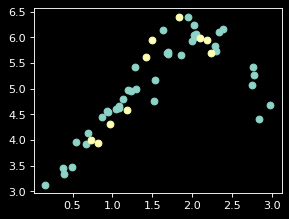

In [4]:
plt.figure(figsize=(4, 3), dpi=80)
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)

## Manual Doing

### Functions

In [5]:
# Define a function for adding a dummy feature (intercept term)
# does not need as polynomial started from 0 degree
# def add_dummy_feature(X):
#     return np.c_[np.ones((X.shape[0], 1)), X]


# Function for create polyomial of given drgree
def make_polynomial(X, degree):
    return np.power(X.reshape(-1, 1), np.arange(0, degree))

In [6]:
def calc_MSE(y, y_pred):
    return np.mean((y - y_pred) ** 2)


# inv causing problem for 6X(>=13) matrix
def estimate_weights(X, y, regu="l2"):
    if regu == "l2":
        lamda_i = add_l2_regu(np.eye(X.shape[1]), l=10)
        return np.linalg.inv(lamda_i + X.T @ X) @ X.T @ y
    else:
        return np.linalg.inv(X.T @ X) @ X.T @ y


def add_l2_regu(I, l):
    return np.dot(l / 2, I)


def train(X, y, use_regu="no"):
    # print(f"x={X},\ny={y.T}")
    W_vector = estimate_weights(X, y, regu=use_regu)
    y_pred = X @ W_vector
    mse = calc_MSE(y, y_pred)
    # print("dim of W_vector:", W_vector.shape, W_vector)
    # print("predicted y is:", y_pred.shape, "\n", y_pred.T)
    print(f"x={X.shape},y={y.shape},w={W_vector.shape},\n train error={mse}", end="")
    return y_pred, W_vector, mse


def test(X, y, W):
    y_pred = X @ W
    mse = calc_MSE(y, y_pred)
    print(f", test error={mse}")
    return y_pred, mse

### train and test

x=(40, 2),y=(40, 1),w=(2, 1),
 train error=0.387279877747339, test error=0.35441345807622293


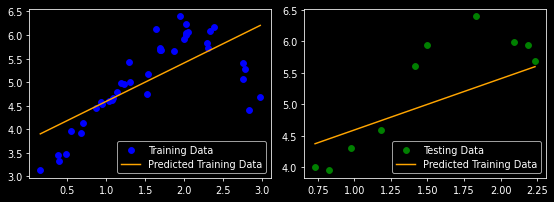

x=(40, 3),y=(40, 1),w=(3, 1),
 train error=0.09999732520946993, test error=0.14787765077247697


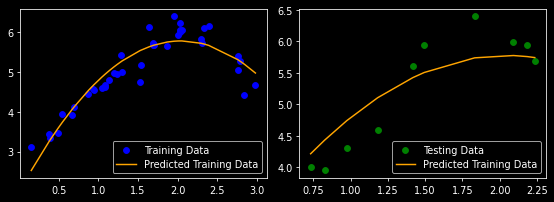

x=(40, 4),y=(40, 1),w=(4, 1),
 train error=0.05299254119655755, test error=0.09007106311469168


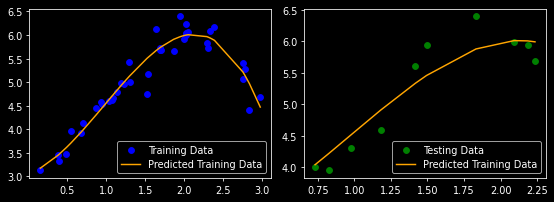

x=(40, 5),y=(40, 1),w=(5, 1),
 train error=0.051917480678284576, test error=0.10245354477587407


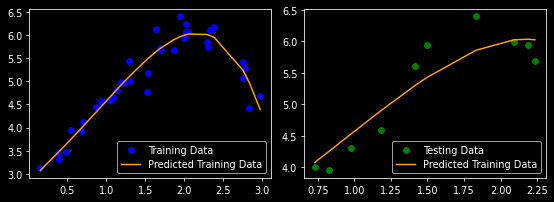

x=(40, 6),y=(40, 1),w=(6, 1),
 train error=0.051232201790110364, test error=0.09986011311583412


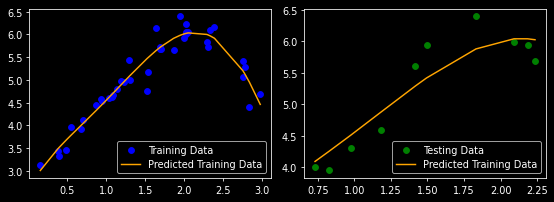

x=(40, 7),y=(40, 1),w=(7, 1),
 train error=0.04753834777665852, test error=0.13061112706858147


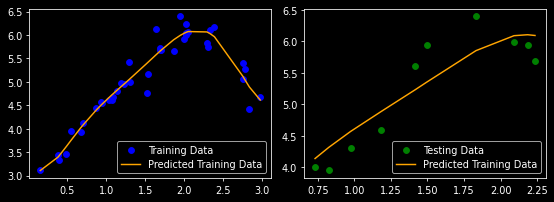

x=(40, 8),y=(40, 1),w=(8, 1),
 train error=0.047311249171663676, test error=0.13205006549325696


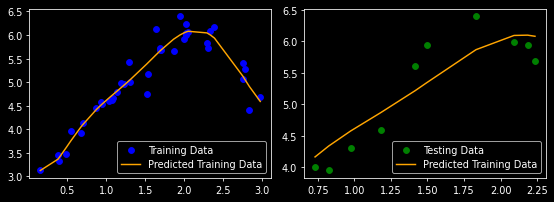

x=(40, 9),y=(40, 1),w=(9, 1),
 train error=0.047110839723255304, test error=0.12843031726809662


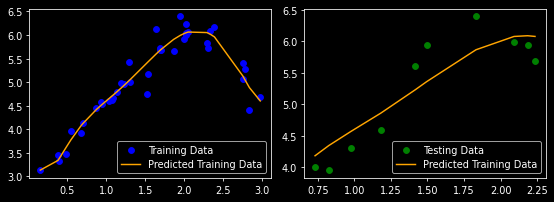

x=(40, 10),y=(40, 1),w=(10, 1),
 train error=0.043864880329494385, test error=0.13271688545343058


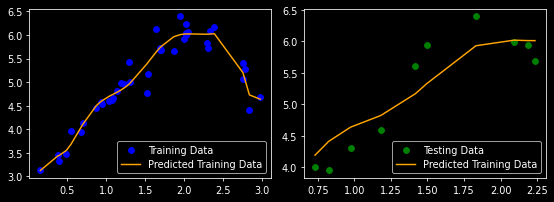

x=(40, 11),y=(40, 1),w=(11, 1),
 train error=0.040191630713373915, test error=0.1211498064254922


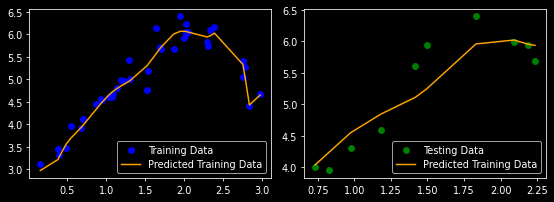

x=(40, 12),y=(40, 1),w=(12, 1),
 train error=1.9710942567033918, test error=0.8272152822940819


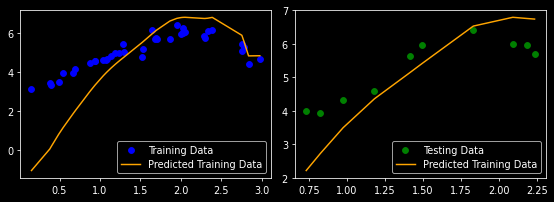

x=(40, 13),y=(40, 1),w=(13, 1),
 train error=408.5996894118142, test error=219.82637519337715


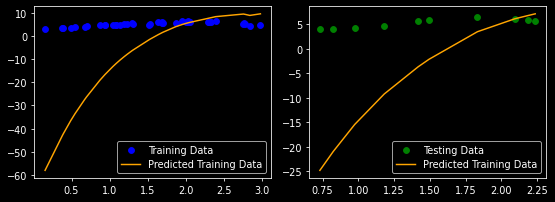

x=(40, 14),y=(40, 1),w=(14, 1),
 train error=805.8527708301202, test error=528.1378502300121


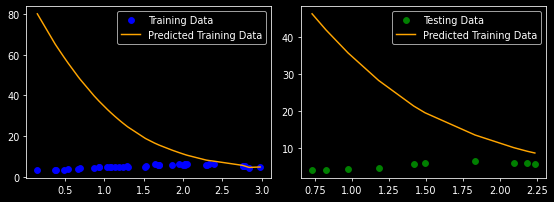

x=(40, 15),y=(40, 1),w=(15, 1),
 train error=9.2776280503216, test error=5.976753994913418


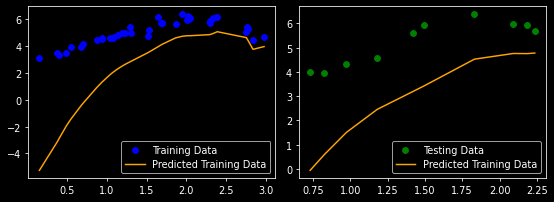

x=(40, 16),y=(40, 1),w=(16, 1),
 train error=103.03823795983749, test error=122.04548968159911


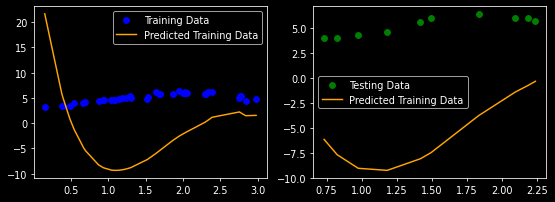

In [7]:
# Finally, plot the MSEs of train and test for varying degree of polynomial
# --- Compute Train and Test Errors for models ranging from linear to a polynomial of degree
# --------------------------------------------------------------------
# Lists to store MSEs for different polynomial degrees
train_errors_mse = []
test_errors_mse = []

train_errors_mse.clear()
test_errors_mse.clear()

for degree in range(1, 16):
    X_poly = make_polynomial(X_train, degree + 1)
    y_p, W_vec, mse = train(X_poly, y_train)
    train_errors_mse.append(mse)
    X_poly_test = make_polynomial(X_test, degree + 1)
    y_p_test, mse_test = test(X_poly_test, y_test, W_vec)
    test_errors_mse.append(mse_test)

    # plotting
    plt.figure(figsize=(8, 3), dpi=70)
    plt.subplot(1, 2, 1)
    plt.scatter(X_train, y_train, label="Training Data", color="blue")
    # plt.scatter(X_train, y_p, label="Predicted Training Data", color="orange")
    sorted_indices = np.argsort(X_train[:, 0])
    plt.plot(
        X_train[sorted_indices],
        y_p[sorted_indices],
        label="Predicted Training Data",
        color="orange",
    )
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(X_test, y_test, label="Testing Data", color="green")
    # plt.scatter(X_test, y_p_test, label="Predicted Testing Data", color="red")
    sorted_indices = np.argsort(X_test[:, 0])
    plt.plot(
        X_test[sorted_indices],
        y_p_test[sorted_indices],
        label="Predicted Training Data",
        color="orange",
    )
    plt.tight_layout()
    plt.legend()
    plt.show()

### error result

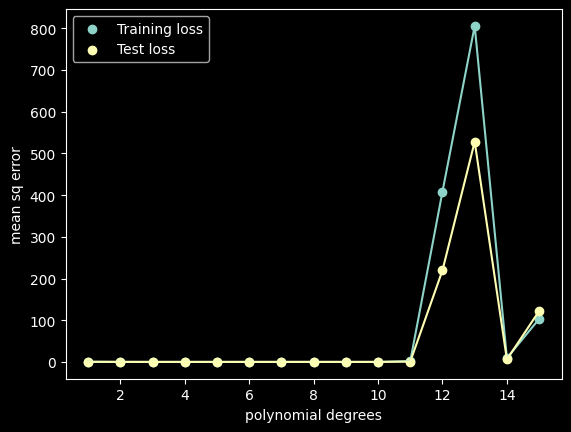

In [8]:
plt.scatter(range(1, 16), train_errors_mse, label="Training loss")
plt.plot(range(1, 16), train_errors_mse)
plt.scatter(range(1, 16), test_errors_mse, label="Test loss")
plt.plot(range(1, 16), test_errors_mse)
plt.xlabel("polynomial degrees")
plt.ylabel("mean sq error")
plt.legend()
plt.show()

## Now using sklearn's 

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

Degree 1: train error=0.3873, test error=0.3544


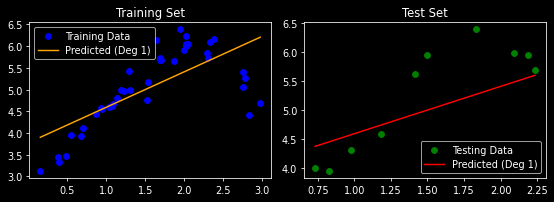

Degree 2: train error=0.1000, test error=0.1479


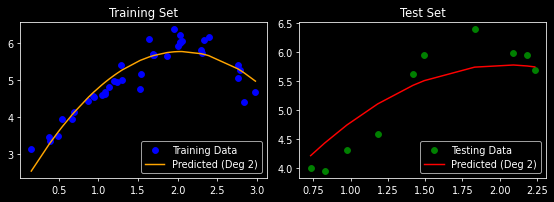

Degree 3: train error=0.0530, test error=0.0901


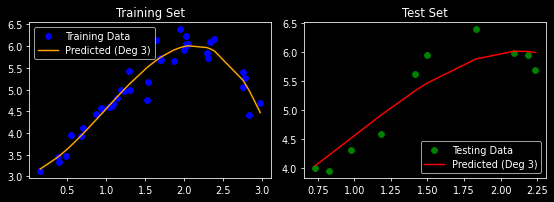

Degree 4: train error=0.0519, test error=0.1025


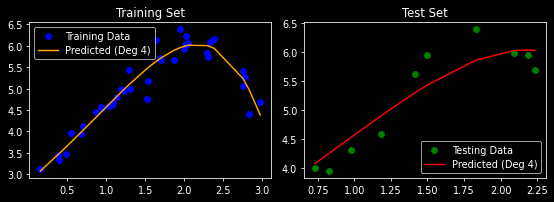

Degree 5: train error=0.0512, test error=0.0999


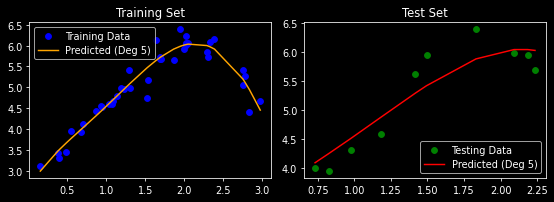

Degree 6: train error=0.0475, test error=0.1306


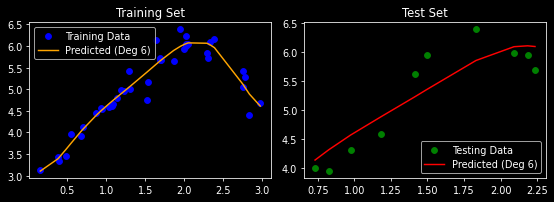

Degree 7: train error=0.0473, test error=0.1321


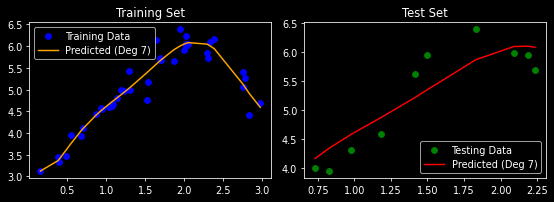

Degree 8: train error=0.0471, test error=0.1284


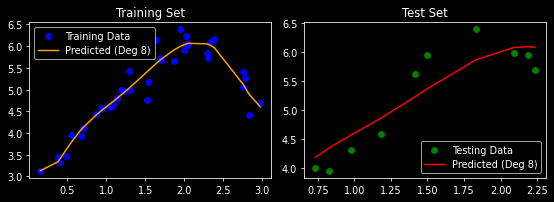

Degree 9: train error=0.0439, test error=0.1325


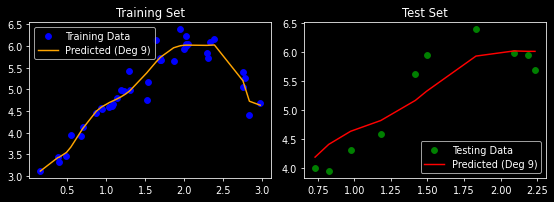

Degree 10: train error=0.0376, test error=0.1256


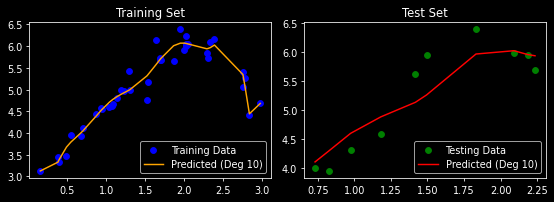

Degree 11: train error=0.0375, test error=0.1248


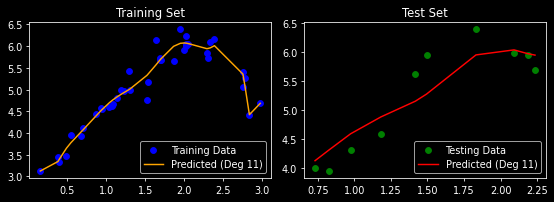

Degree 12: train error=0.0356, test error=0.1258


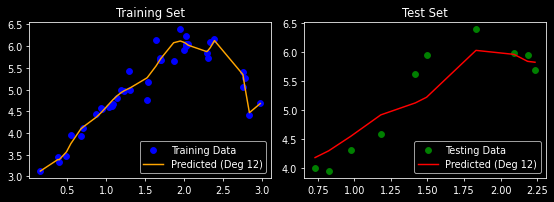

Degree 13: train error=0.0356, test error=0.1266


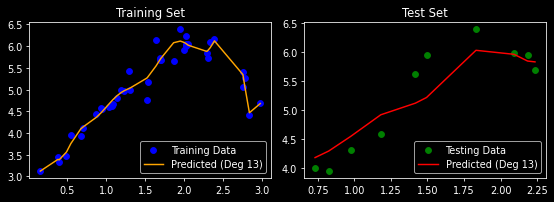

Degree 14: train error=0.0354, test error=0.1306


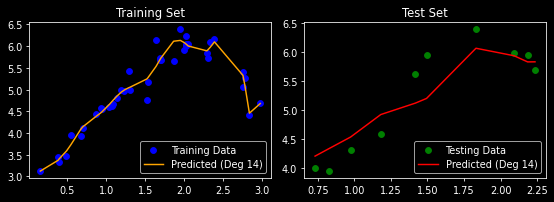

Degree 15: train error=0.0352, test error=0.1290


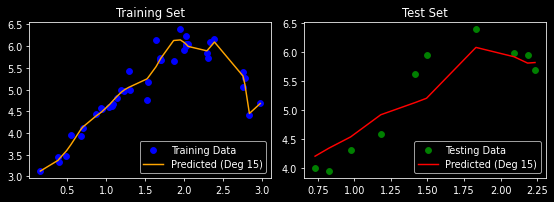

In [10]:
# Lists to store MSEs for different polynomial degrees
train_errors_mse = []
test_errors_mse = []

for degree in range(1, 16):
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Calculate and store MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_errors_mse.append(train_mse)
    test_errors_mse.append(test_mse)
    print(f"Degree {degree}: train error={train_mse:.4f}, test error={test_mse:.4f}")

    # Plotting
    plt.figure(figsize=(8, 3), dpi=70)
    plt.subplot(1, 2, 1)
    plt.scatter(X_train, y_train, label="Training Data", color="blue")
    X_train_sorted = np.sort(X_train, axis=0)
    y_train_pred_sorted = model.predict(poly_features.transform(X_train_sorted))
    plt.plot(
        X_train_sorted,
        y_train_pred_sorted,
        color="orange",
        label=f"Predicted (Deg {degree})",
    )
    plt.title("Training Set")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(X_test, y_test, label="Testing Data", color="green")
    X_test_sorted = np.sort(X_test, axis=0)
    y_test_pred_sorted = model.predict(poly_features.transform(X_test_sorted))
    plt.plot(
        X_test_sorted,
        y_test_pred_sorted,
        color="red",
        label=f"Predicted (Deg {degree})",
    )
    plt.title("Test Set")
    plt.legend()
    plt.tight_layout()
    plt.show()

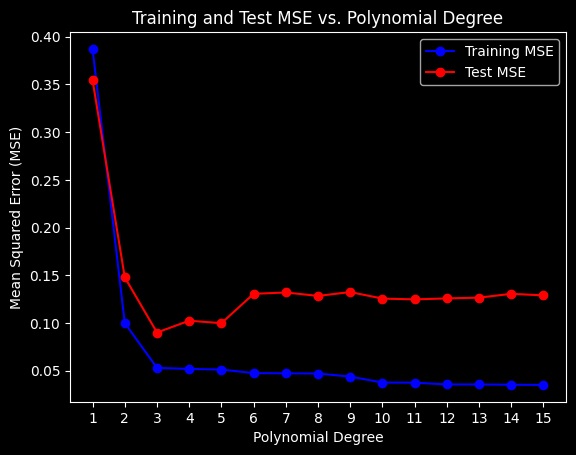

In [11]:
# Plot the MSEs for all degrees
plt.plot(range(1, 16), train_errors_mse, marker="o", color="blue", label="Training MSE")
plt.plot(range(1, 16), test_errors_mse, marker="o", color="red", label="Test MSE")

plt.title("Training and Test MSE vs. Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.xticks(range(1, 16))
plt.legend()
# plt.grid(True)
plt.show()